In [119]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [120]:
# read the words
with open('names.txt', 'r') as file:
    words = file.read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [121]:
len(words)

32033

In [122]:
# build vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [123]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []

for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append context

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [124]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [125]:
C = torch.randn((27, 2))

In [126]:
C[5]
# F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([ 0.1061, -0.5564])

In [127]:
C[X].shape

torch.Size([32, 3, 2])

In [128]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [129]:
W1 = torch.randn((6, 100)) # context_block * embedding_dim, num of neurons
b1 = torch.randn((100))

In [130]:
# broadcasting is correct
h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1)

### alternative way
# h = emb.view(-1, 6) @ W1 + b1

In [131]:
h

tensor([[-0.9970, -0.9830,  0.6733,  ..., -0.9983, -0.5466, -0.9988],
        [-0.6916, -0.9896,  0.4139,  ..., -0.9927,  0.5328, -0.8697],
        [-0.9953, -0.9998,  0.8066,  ...,  0.9383, -0.0610,  0.5592],
        ...,
        [-0.9642,  0.9251, -0.6467,  ..., -0.9995,  0.8546, -0.4726],
        [-0.9996, -0.9904,  0.6280,  ..., -0.9769, -0.6497, -0.9913],
        [ 0.8982, -0.8937, -0.9777,  ..., -0.9968,  0.9830,  0.7381]])

In [132]:
h.shape

torch.Size([32, 100])

In [133]:
### Inefficient way of doing this because new memory is created
# torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

In [134]:
### Inefficient way of doing this because new memory is created
# torch.cat(torch.unbind(emb, 1), 1).shape

In [135]:
# emb.view((32, 6)) == torch.cat(torch.unbind(emb, 1), 1)

In [136]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [137]:
logits = h @ W2 + b2

In [138]:
logits.shape

torch.Size([32, 27])

In [139]:
counts = logits.exp()

In [140]:
prob = counts / counts.sum(1, keepdim=True)

In [141]:
prob.shape

torch.Size([32, 27])

In [142]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(15.6651)

In [143]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

## Code made more respectable :)

In [144]:
X.shape, Y.shape # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [145]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [146]:
sum(p.nelement() for p in parameters)

3481

In [147]:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdims=True)
# loss = -prob[torch.arange(32), Y].log().mean()
loss = F.cross_entropy(logits, Y)
loss

tensor(17.7697)

### Reasons to use inbuilt torch functions like cross-entropy instead of writing logits and probs:
<li>Each variable creates a new tensor requiring new memory which increases the memory required and is inefficient</li>
<li>Every tensor is stored as one array of numbers and the inbuilt pytorch operations like .view() leverage this and do the numerical operations using fused kernels with high efficiency</li>
<li>In the case of F.cross_entropy - pytorch looks at largest positive number in logits and subtracts it so that we have numerical stability instead of nans coming in those cases</li>

## Neural net training

In [148]:
# build the dataset

def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []

    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append context

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [214]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [215]:
sum(p.nelement() for p in parameters)

11897

In [216]:
# important! do not forget
for p in parameters:
    p.requires_grad = True

In [217]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

In [218]:
lri = []
lossi = []
stepi = []

In [219]:
for i in range(200000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

2.261230945587158


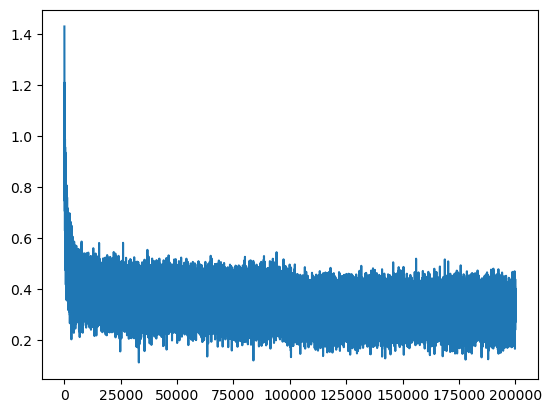

In [220]:
plt.plot(stepi, lossi)

In [203]:
# logits.max(1)

In [221]:
emb = C[Xtr] # (n_words, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (n_words, 100)
logits = h @ W2 + b2 # (n_words, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1171, grad_fn=<NllLossBackward0>)

In [222]:
emb = C[Xdev] # (n_words, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (n_words, 100)
logits = h @ W2 + b2 # (n_words, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1574, grad_fn=<NllLossBackward0>)

In [171]:
# plt.plot(lre, lossi)

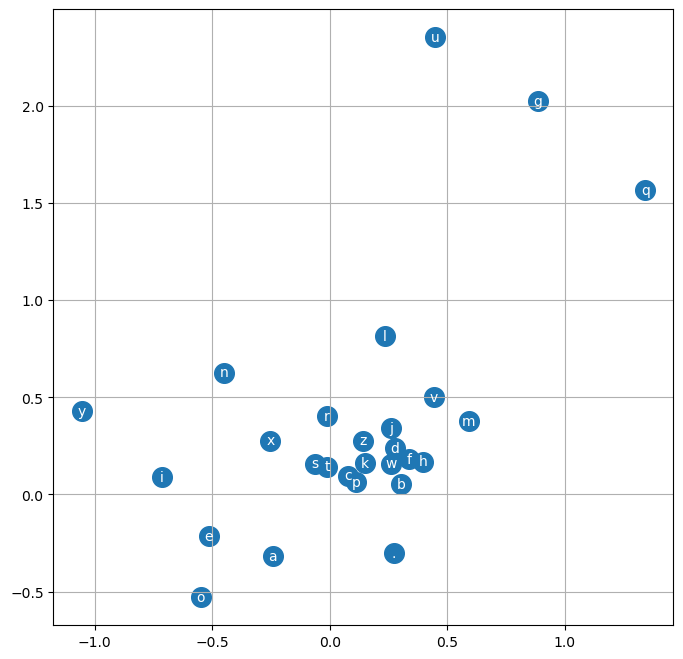

In [195]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

### sample names from the model

In [223]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim = 1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

carmahzamille.
khi.
mis.
reh.
cassanden.
jazhuel.
den.
arci.
geni.
ner.
kia.
chaiivia.
leigh.
ham.
pope.
quinn.
shonne.
liven.
arson.
ogiearyni.
